## CUSTOMER CHURN PREDICTION

### EXPLORATORY DATA ANALYSIS CARRIED OUT BY:
##### AYEVBOSA AJAYI - EBOHON - ayevbosaa0@gmail.com
##### SIYANBOLA OLUWATOBI ABIGAIL - siyanbolao910@gmail.com

### MODEL DEVELOPMENT AND EVALUATION
#### PREPARED BY:
##### OBA OLAITAN - obaolaitan3@gmail.com
##### TEMILOLUWA MAYOWA AWOYEMI - awoyemitemi2019@gmail.com
##### IBEKWE GHISLIAN CHIGOZIE - chogozieghislian@gmaiL.com

### ESSAY WRITE-UP(OVERVIEW, EXPLANATIONS AND CONCLUSIONS) CARRIED OUT BY:
#### OMOTOSO FIYINFOLUWA VICTORIA - victoriaomotoso0303@gmail.com
#### SHODIJO HEPHZIBAH OLAMIDE - shodijohephzibah2005@gmail.com

## OVERVIEW

Customer churn is one of the more pressing problems banks deal with. When customers leave, it hits revenue hard, and the tricky part is that most institutions only notice after the fact. This project takes a proactive approach by using machine learning to predict which customers are likely to churn before they actually do.

The dataset used includes a range of customer information, from credit scores and account balances to how long someone has been with the bank and whether they actively use their account. The target variable simply tells us whether a customer stayed or left.

The analysis starts with exploratory data analysis to get a feel for the data, looking at distributions, spotting outliers, and finding early signals of what separates churners from loyal customers. From there, the data is cleaned and prepared for modeling. Categorical variables like gender and geography are encoded numerically, and the dataset is split into training and testing sets.

Three models are built and compared. Logistic Regression serves as the baseline since it is straightforward and easy to interpret. A Decision Tree is added to capture more complex patterns in the data. Finally, a Random Forest model is used as the strongest of the three, combining multiple decision trees to produce more reliable predictions.

Each model is evaluated using accuracy scores and confusion matrices. The Random Forest also provides a feature importance breakdown, which helps identify the customer attributes that matter most when it comes to predicting churn. The goal throughout is to show how machine learning can turn raw customer data into actionable insights that support smarter retention decisions.

### EXPLORATORY DATA ANALYSIS CARRIED OUT BY:
##### AYEVBOSA AJAYI - EBOHON - ayevbosaa0@gmail.com
##### SIYANBOLA OLUWATOBI ABIGAIL - siyanbolao910@gmail.com

In [2]:
# importing the necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn import tree
from sklearn.tree import DecisionTreeRegressor

In [3]:
# loading the dataset

df = pd.read_csv('C:\\Users\\Hp\\Documents\\CPD\\Churn Modeling.csv')

#### DATASET OVERVIEW

In [4]:
# gives the datasets size and dimensions

df.shape

(10000, 14)

In [5]:
df.head()

# prints out the first 5 rows of the dataset

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
# Displays dataset structure including column names, data types, and null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [7]:
# this will give us the statistical summary of the numerical columns of the dataset
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [8]:
# Drop identifier columns that add no predictive value
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [9]:
# Check for missing values across all columns
df.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

> From the output, the dataset contains no missing values across all columns, so no imputation or dropping of records is required.

In [10]:
# Check for zero values
# some may be valid (e.g. zero balance) while others could indicate missing or invalid data
(df == 0).sum()

CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure              413
Balance            3617
NumOfProducts         0
HasCrCard          2945
IsActiveMember     4849
EstimatedSalary       0
Exited             7963
dtype: int64

> Looking at the output, the zero values present in Tenure, Balance, HasCrCard, IsActiveMember, and Exited are not a cause for concern. They are all valid within this dataset, as a customer can genuinely have a zero balance, no credit card, or have just joined the bank.

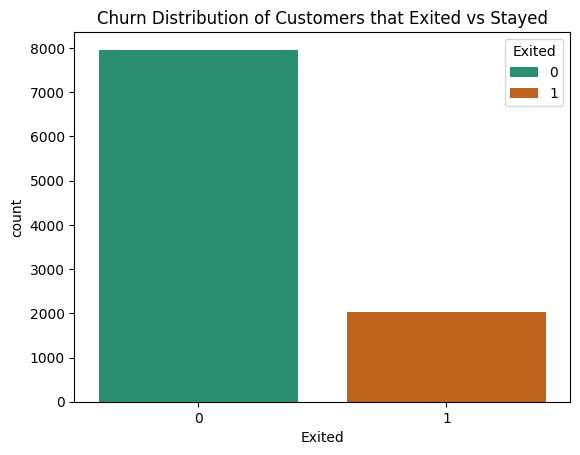

In [11]:
### Target Variable Exploration
# this visualizes the difference between customers who stayed and customers who exited
sns.countplot(x='Exited', data=df, hue="Exited", palette="Dark2")
plt.title('Churn Distribution of Customers that Exited vs Stayed')
plt.show()

> From the plot, the dataset is clearly imbalanced. The majority of customers, around 8000, did not churn, while roughly 2000 did. This roughly 80/20 split is worth keeping in mind during modeling, as it can cause a classifier to be biased toward predicting the majority class.

In [12]:
# this will give us the percentage distribution of the exited column
#as it will help us to understand the proportion of customesrs who churned and those who stayed with the company (bank)
counts = df['Exited'].value_counts(normalize=True) * 100
counts.index = ['Stayed', 'Left']
print(counts)

Stayed    79.63
Left      20.37
Name: proportion, dtype: float64


> Approximately 80% of customers remained with the company, while 20% chunned.
This indicates a moderate churn rate, suggesting that retention focused initiatives could be valuable

### DISTRIBUTION OF NUMERICAL FEATURES 

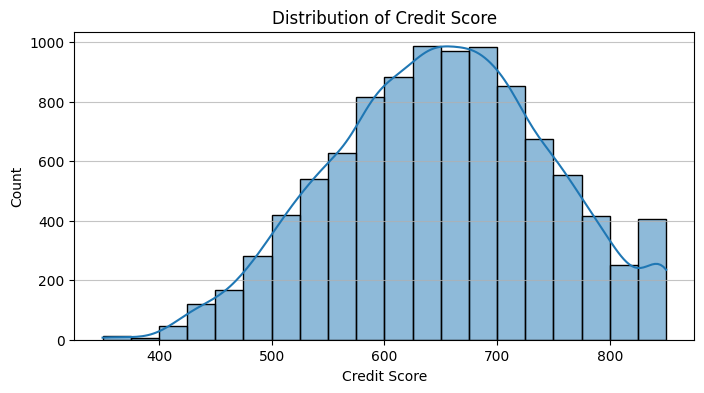

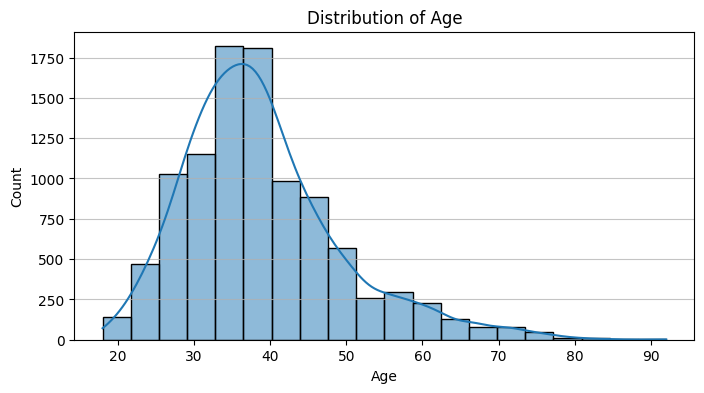

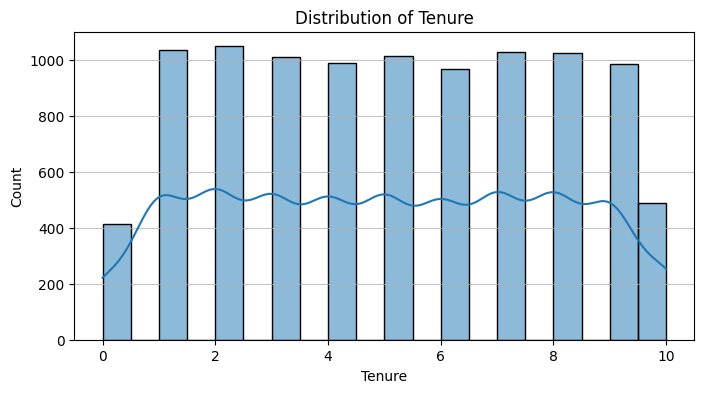

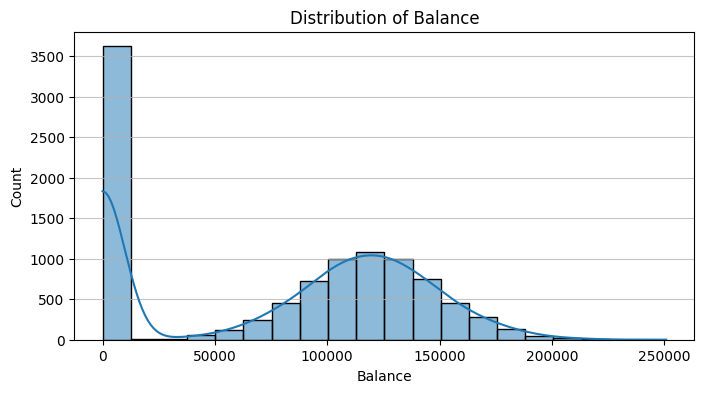

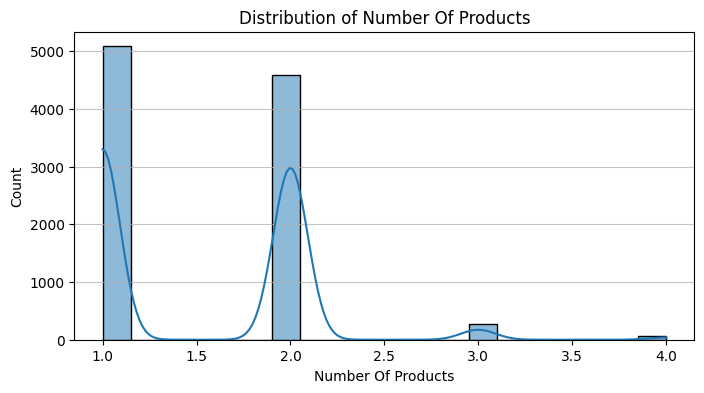

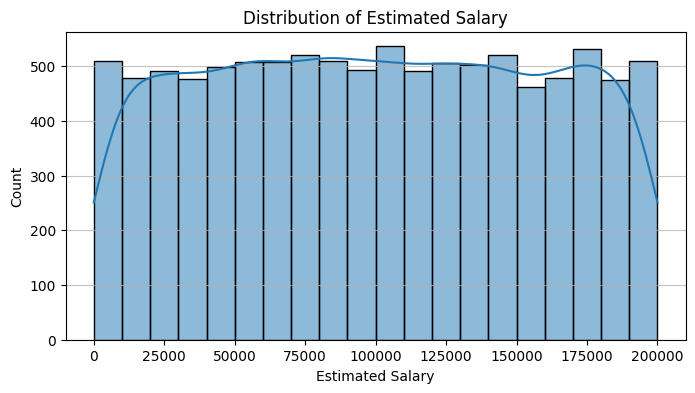

In [13]:
# Visualization of the distribution of the numerical features using histogram plots

plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='CreditScore', kde=True, bins=20)
plt.title('Distribution of Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='Age', kde=True, bins=20)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='Tenure', kde=True, bins=20)
plt.title('Distribution of Tenure')
plt.xlabel('Tenure')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='Balance', kde=True, bins=20)
plt.title('Distribution of Balance')
plt.xlabel('Balance')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='NumOfProducts', kde=True, bins=20)
plt.title('Distribution of Number Of Products')
plt.xlabel('Number Of Products')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='EstimatedSalary', kde=True, bins=20)
plt.title('Distribution of Estimated Salary')
plt.xlabel('Estimated Salary')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

> CreditScore is roughly symmetric, which is fairly typical for a large customer base. Age skews slightly right, meaning the data leans more toward middle aged customers than younger ones. Tenure is evenly spread with no strong bias toward new or long standing accounts. Balance shows a bimodal pattern, a large concentration at zero and a separate cluster of higher value accounts, which is pretty common in retail banking. NumOfProducts is heavily skewed toward 1 and 2, with very few customers holding more than that. EstimatedSalary looks almost uniformly distributed, which suggests it could be synthetic or pre-binned. Nothing here demands immediate transformation, though the zero heavy Balance column is worth keeping in mind going into modeling.

### DISTRIBUTION OF NUMERICAL FEATURES AGAINST THE TARGET FEATURE

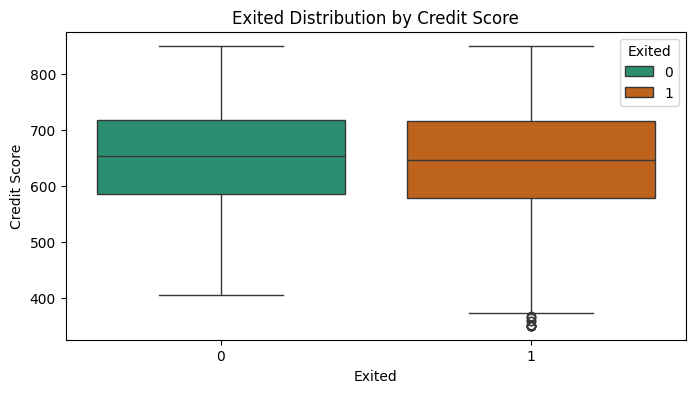

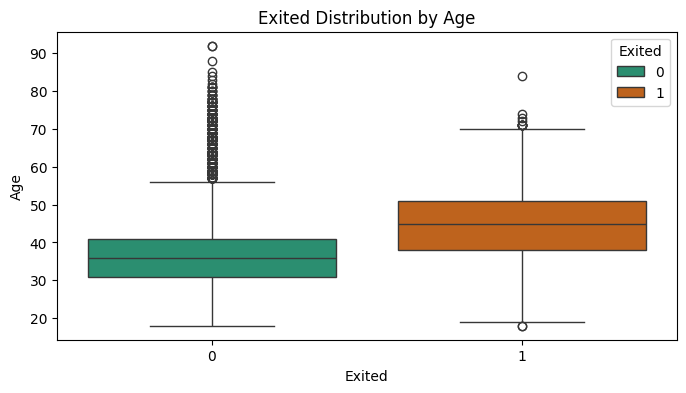

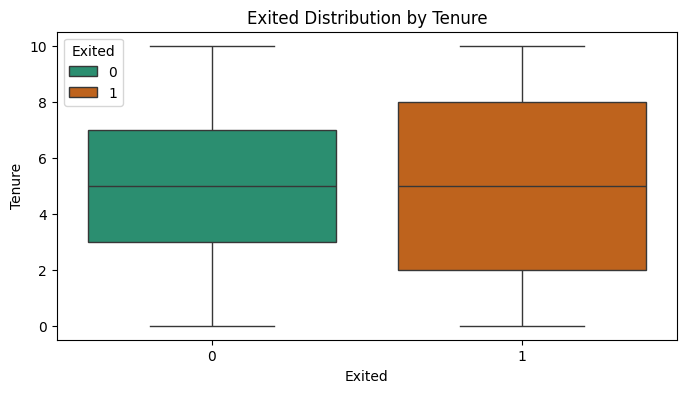

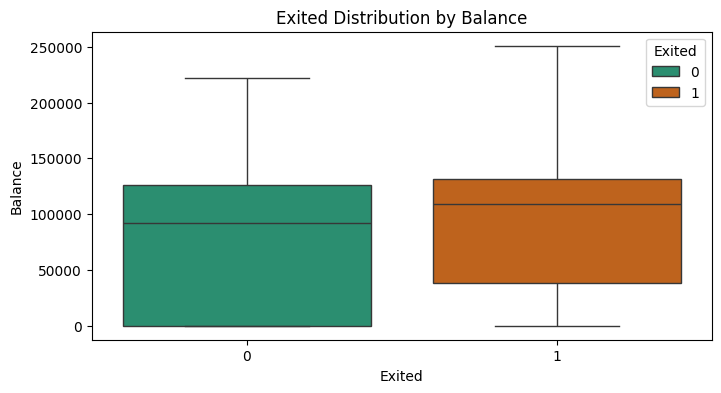

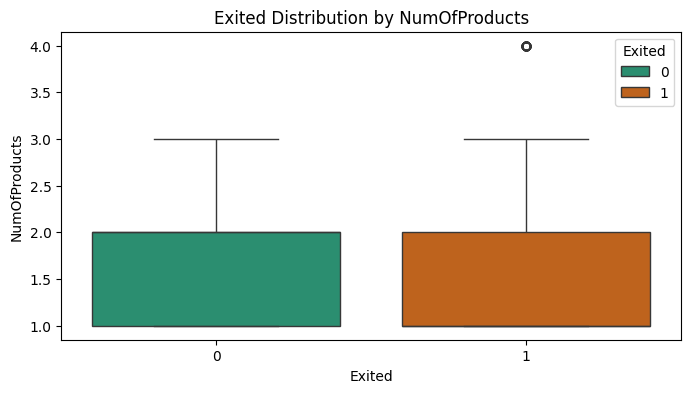

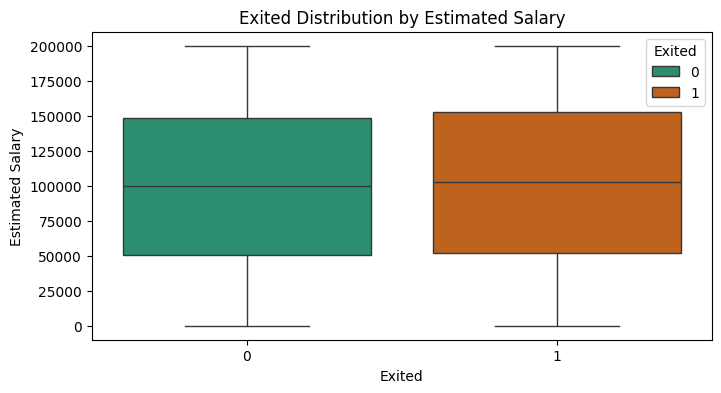

In [14]:
# Visualize the distribution of numerical features against the target variable using boxplots

# Visualization of the distribution of numerical features against the target feature using histogram plots

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Exited', y='CreditScore', hue='Exited', palette="Dark2")
plt.title("Exited Distribution by Credit Score")
plt.xlabel("Exited")
plt.ylabel("Credit Score")
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Exited', y='Age', hue='Exited', palette="Dark2")
plt.title("Exited Distribution by Age")
plt.xlabel("Exited")
plt.ylabel("Age")
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Exited', y='Tenure', hue='Exited', palette="Dark2")
plt.title("Exited Distribution by Tenure")
plt.xlabel("Exited")
plt.ylabel("Tenure")
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Exited', y='Balance', hue='Exited', palette="Dark2")
plt.title("Exited Distribution by Balance")
plt.xlabel("Exited")
plt.ylabel("Balance")
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Exited', y='NumOfProducts', hue='Exited', palette="Dark2")
plt.title("Exited Distribution by NumOfProducts")
plt.xlabel("Exited")
plt.ylabel("NumOfProducts")
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Exited', y='EstimatedSalary', hue='Exited', palette="Dark2")
plt.title("Exited Distribution by Estimated Salary")
plt.xlabel("Exited")
plt.ylabel("Estimated Salary")
plt.show()

### CATEGORICAL FEATURES DISTRIBUTION

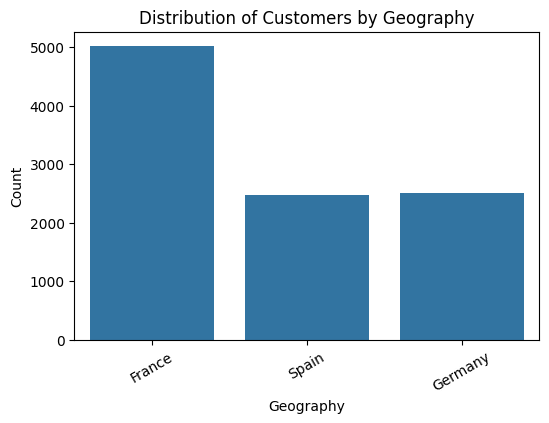

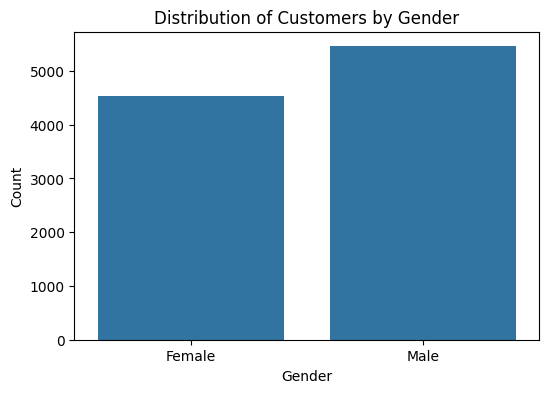

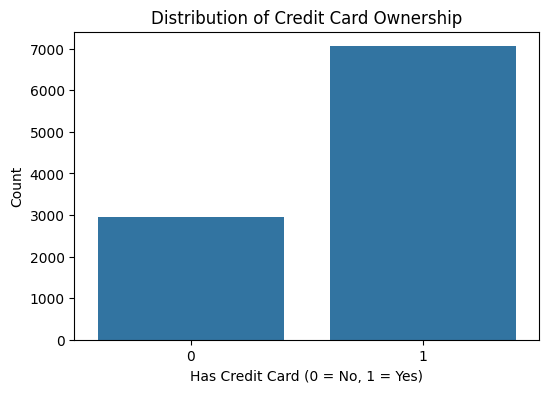

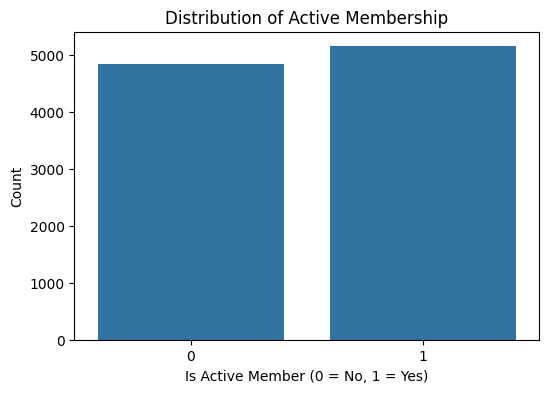

In [15]:
# Visualization of the distribution of the categorical features

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Geography')
plt.title('Distribution of Customers by Geography')
plt.xlabel('Geography')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Gender')
plt.title('Distribution of Customers by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='HasCrCard')
plt.title('Distribution of Credit Card Ownership')
plt.xlabel('Has Credit Card (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='IsActiveMember')
plt.title('Distribution of Active Membership')
plt.xlabel('Is Active Member (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

> Most customers in the dataset are based in France, with Germany and Spain making up smaller shares. Gender is fairly balanced between male and female. The majority of customers hold a credit card, and a good portion are active members. Nothing here stands out as a severe imbalance worth worrying about.

#### DISTRIBUTION OF CATEGORICAL FEATURES AGAINST TARGET FEATURE

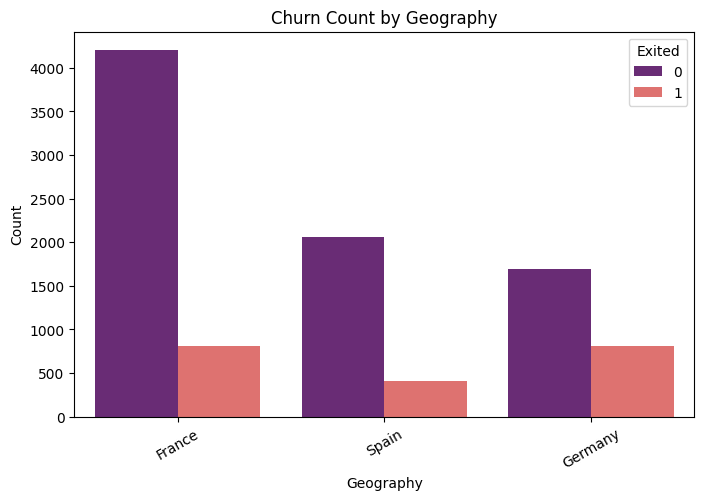

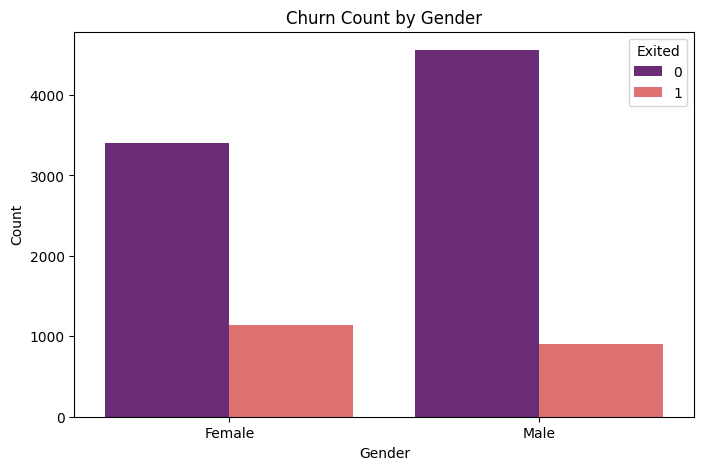

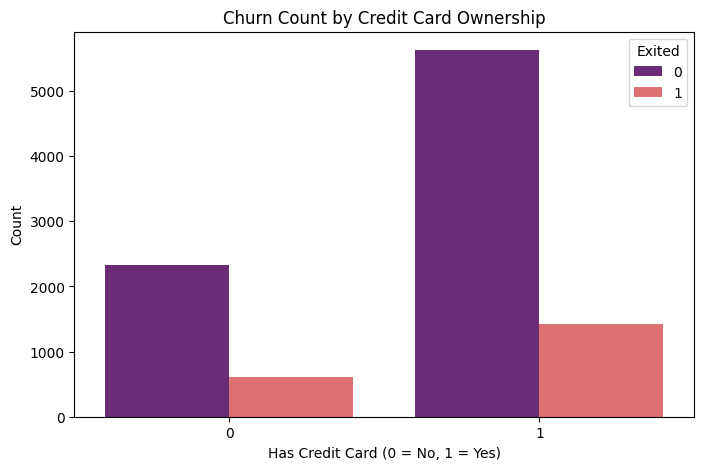

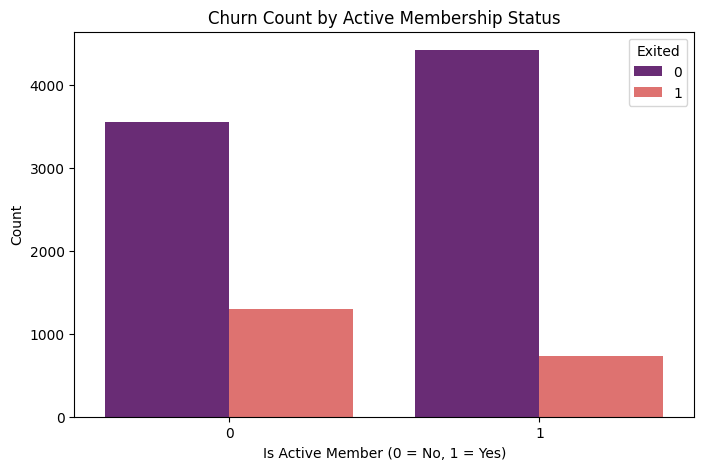

In [16]:
## Visualization of the distribution of the categorical features against the target feature

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Geography", hue="Exited", palette="magma")
plt.title("Churn Count by Geography")
plt.xlabel("Geography")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Gender", hue="Exited", palette="magma")
plt.title("Churn Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="HasCrCard", hue="Exited", palette="magma")
plt.title("Churn Count by Credit Card Ownership")
plt.xlabel("Has Credit Card (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="IsActiveMember", hue="Exited", palette="magma")
plt.title("Churn Count by Active Membership Status")
plt.xlabel("Is Active Member (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

> Churn rates do vary across the categorical features. Germany stands out with a noticeably higher churn rate compared to France and Spain. Gender does not seem to make much of a difference. Customers without a credit card churn slightly more, though the gap is not dramatic. The most notable finding here is that inactive members churn at a much higher rate, which suggests that engagement is one of the stronger indicators of whether a customer stays or leaves.

#### CORRELATION HEAT MAP

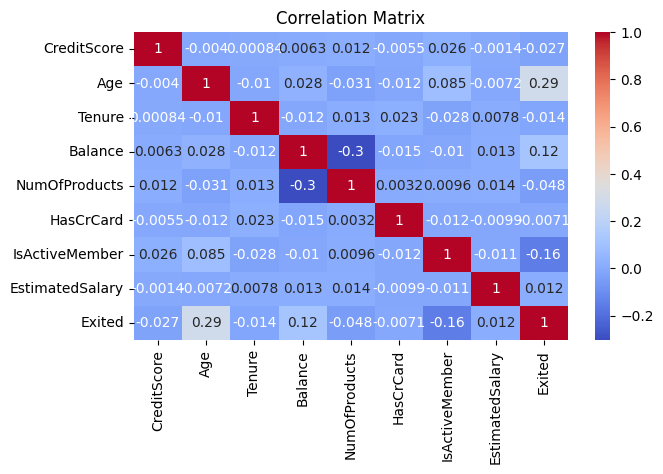

In [17]:
# This will allow us to identify features with strong correlation 
# which will be helpful in understanding the relationship between the features

plt.figure(figsize=(7, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title('Correlation Matrix')
plt.show()

> Most of the features show very weak correlations with each other, which is a good sign going into logistic regression since multicollinearity is not a major concern here. In terms of churn, Age has the most notable positive correlation at 0.29, so older customers are more likely to leave. IsActiveMember sits at -0.16, which lines up with what we saw earlier, inactive customers churn more. Balance has a slight positive correlation with churn at 0.12. The -0.3 between Balance and NumOfProducts is the strongest inter-feature correlation in the matrix, but it is not alarming. Overall the features are reasonably independent, which is what you want before fitting a logistic regression model.

### MODEL DEVELOPMENT AND EVALUATION
#### PREPARED BY:
##### OBA OLAITAN - obaolaitan3@gmail.com
##### TEMILOLUWA MAYOWA AWOYEMI - awoyemitemi2019@gmail.com
##### IBEKWE GHISLIAN CHIGOZIE - chogozieghislian@gmaiL.com

In [18]:
# importing the necessary libraries

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn import tree
from sklearn.tree import DecisionTreeRegressor

In [19]:
# checking for missing values

df.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

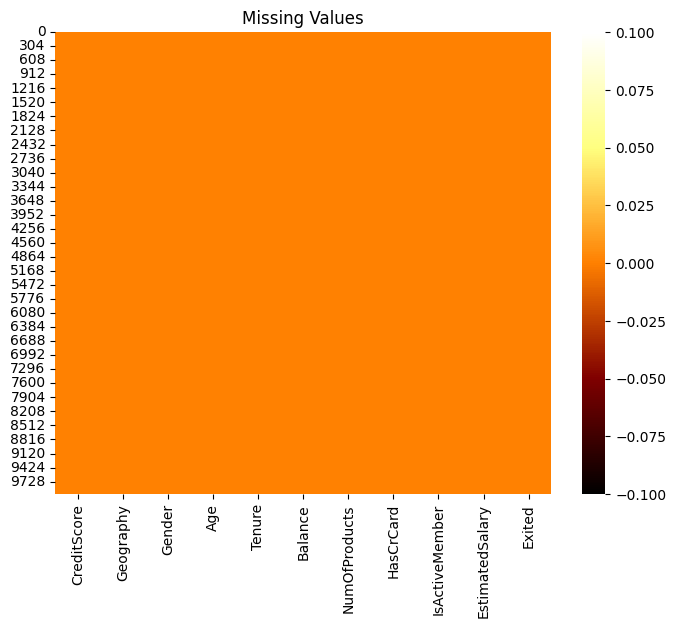

In [20]:
# Visualization of measing values using heatmap

plt.figure(figsize=(8, 6))
sns.heatmap(df.isnull(), cmap='afmhot')
plt.title('Missing Values')
plt.show()

> The visualization confirms there are no missing values in the dataset. Since logistic regression requires numerical input, categorical variables like Geography and Gender need to be encoded before modeling. This is handled using one-hot encoding, which converts each category into a binary column the model can work with.

In [21]:
# Gender and Geography are categorical and need to be numerical before modeling.

# OneHotEncoder converts each category into binary columns, which are then

# merged back into the dataframe after dropping the original columns.

encoder = OneHotEncoder(sparse_output=False)
encoded = encoder.fit_transform(df[['Gender', 'Geography']])
encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(['Gender', 'Geography'])
)
df = df.drop(columns=['Gender', 'Geography'])
df = pd.concat([df, encoded_df], axis=1)

In [22]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Gender_Female,Gender_Male,Geography_France,Geography_Germany,Geography_Spain
0,619,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,1.0,0.0,0.0
1,608,41,1,83807.86,1,0,1,112542.58,0,1.0,0.0,0.0,0.0,1.0
2,502,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,1.0,0.0,0.0
3,699,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,1.0,0.0,0.0
4,850,43,2,125510.82,1,1,1,79084.10,0,1.0,0.0,0.0,0.0,1.0


### LOGISTIC REGRESSION MODEL

In [23]:
# Split the dataset into features (x) and target (y), then divide into

# training and test sets using an 80/20 split with stratification to

# preserve the class distribution across both subsets.

x = df[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
      'IsActiveMember', 'EstimatedSalary', 'Gender_Female', 'Gender_Male',
     'Geography_France', 'Geography_Germany', 'Geography_Spain']]
y = df['Exited']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

> The dataset is split into features and the target variable, with Exited as what we are trying to predict. An 80/20 train-test split is used, meaning the model trains on 80% of the data and is evaluated on the remaining 20%. Stratification is applied to ensure both subsets maintain the same churn ratio, which is important given the class imbalance noted earlier.

In [24]:
# Train a Logistic Regression model on the training data.
# max_iter is set high to ensure the model converges properly.
# class_weight='balanced' is used to account for the class imbalance
# by giving more weight to the minority class (churners) during training.
model_df = LogisticRegression(max_iter=10000, class_weight='balanced')
model_df.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [25]:
# Predict on training data and preview the first 10 predictions
y_train_pred = model_df.predict(x_train)
print(y_train_pred[:10])

[1 1 1 0 1 0 0 0 0 0]


In [26]:
# Compare actual vs predicted values side by side to get a quick
# visual check of how well the model is performing on the training set
res_df = pd.DataFrame(
    {'Actual': y_train,
     'Predicted': y_train_pred}
)
print(
    "Actual vs Predicted values:"
)
display(
    res_df.head(5)
)

Actual vs Predicted values:


,Actual,Predicted
2151,1,1
8392,1,1
5006,0,1
4117,0,0
7182,0,1


In [27]:
# Generate predictions on the test set and preview the first 10 results
y_test_pred = model_df.predict(x_test)
print(y_test_pred[:10])

[0 1 0 0 0 0 0 1 1 0]


In [28]:
# Compare actual vs predicted values on the test set
res_df = pd.DataFrame(
    {'Actual': y_test,
     'Predicted': y_test_pred}
)
display(res_df.head())

,Actual,Predicted
5702,0,0
3667,0,1
1617,0,0
5673,0,0
4272,0,0


In [29]:
# Extract model coefficients as a proxy for feature importance.
# Higher positive coefficients increase churn probability,
# while negative ones reduce it.
feat_imp = pd.DataFrame(
    {'Feature': x.columns,
     'Coefficient': model_df.coef_[0]}
)
feat_imp = feat_imp.sort_values(
    'Coefficient', ascending=False
)
display(feat_imp)

,Feature,Coefficient
10,Geography_Germany,1.535164e-01
1,Age,7.596037e-02
3,Balance,2.716402e-06
6,EstimatedSalary,8.840736e-07
0,CreditScore,-9.435983e-04
2,Tenure,-6.653961e-03
4,NumOfProducts,-1.210154e-01
7,Gender_Female,-3.120681e-01
11,Geography_Spain,-6.349301e-01
9,Geography_France,-6.883688e-01


In [30]:
# Evaluate model performance on the training set using accuracy score
y_train_pred = model_df.predict(x_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy: {train_accuracy:.4f}")

Training Accuracy: 0.7103


In [31]:
# Evaluate model performance on the test set using accuracy score
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Testing Accuracy: {test_accuracy:.4f}")

Testing Accuracy: 0.7145


In [32]:
# Confusion matrix breaks down correct and incorrect predictions
# into true positives, true negatives, false positives, and false negatives
print(f"\nConfusion Matrix (Test Set):")
cm = confusion_matrix(y_test, y_test_pred)
print(cm)


Confusion Matrix (Test Set):
[[1142  451]
 [ 120  287]]


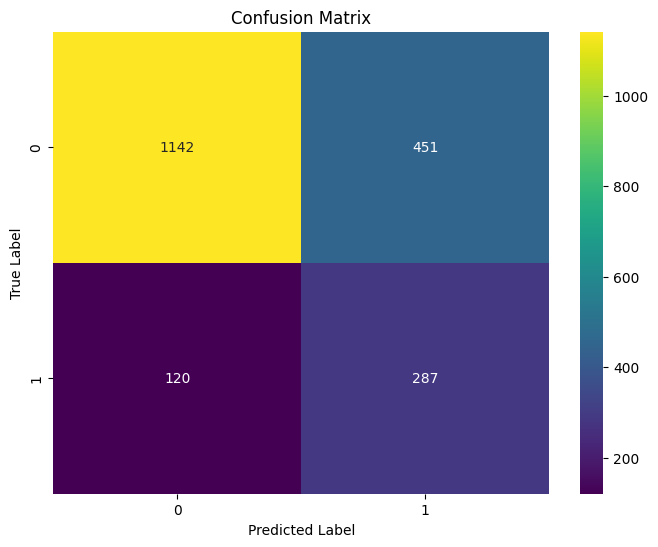

In [33]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

 The model was trained with class_weight='balanced' to account for the imbalance between churned and non-churned customers. Predictions were generated on both the training and test sets and checked against the actual labels as a quick sanity check. Feature importance from the model coefficients shows that Geography_Germany and Age have the strongest positive relationship with churn, while IsActiveMember is the strongest negative coefficient, confirming that active members are far less likely to leave. The model achieved a training accuracy of 71.03% and a test accuracy of 71.45%. While this is lower than a default model would produce, the confusion matrix tells a better story, with 287 churners correctly identified and false negatives reduced significantly. For a churn prediction task, catching actual churners matters more than raw accuracy, and the balanced model reflects that priority.

#### DECISION TREE REGRESSOR

In [34]:
# The same feature set and target variable are reused from the logistic regression.
# The 80/20 stratified split is kept consistent to ensure fair comparison
# across all three models.
x = df[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
      'IsActiveMember', 'EstimatedSalary', 'Gender_Female', 'Gender_Male',
     'Geography_France', 'Geography_Germany', 'Geography_Spain']]
y = df['Exited']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [35]:
# Train a Decision Tree Regressor with controlled depth and leaf size
# to prevent overfitting on the training data.
df_regressor = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)
df_regressor.fit(x_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

> A Decision Tree Regressor is trained on the data. max_depth limits how deep the tree grows, min_samples_split controls the minimum samples needed to split a node, and min_samples_leaf ensures each leaf has enough data points. These constraints work together to prevent the model from memorizing the training data.

In [36]:
# Generate continuous predictions on the training set
y_pred_train = df_regressor.predict(x_train)
print(y_pred_train)

[0.91304348 0.17391304 0.21621622 ... 0.03448276 0.         0.61290323]


> Unlike the logistic regression which outputs clean 0s and 1s, the Decision Tree Regressor outputs continuous values between 0 and 1, representing the proportion of churners in each leaf node. These will need to be converted to binary labels before evaluation.

In [37]:
# Generate continuous predictions on the test set
y_pred_test = df_regressor.predict(x_test)
print(y_pred_test)

[0.         0.09090909 0.         ... 0.9        0.         0.07739308]


> The same continuous predictions are now made on the unseen test data. This is the more critical set since the model had no exposure to it during training.

In [38]:
# Extract and rank feature importance scores from the Decision Tree
feature_importance = pd.DataFrame({
    'feature': x.columns,
    'importance': df_regressor.feature_importances_
}).sort_values('importance', ascending=False)

display(feature_importance)

,feature,importance
1,Age,0.361111
4,NumOfProducts,0.243426
3,Balance,0.112226
5,IsActiveMember,0.102866
6,EstimatedSalary,0.045739
0,CreditScore,0.044779
10,Geography_Germany,0.043649
2,Tenure,0.028389
7,Gender_Female,0.006579
8,Gender_Male,0.005746


> Unlike logistic regression which uses coefficients, the Decision Tree measures feature importance based on how much each feature reduces impurity across all splits. Features ranked higher are relied on more heavily when the tree makes its decisions.



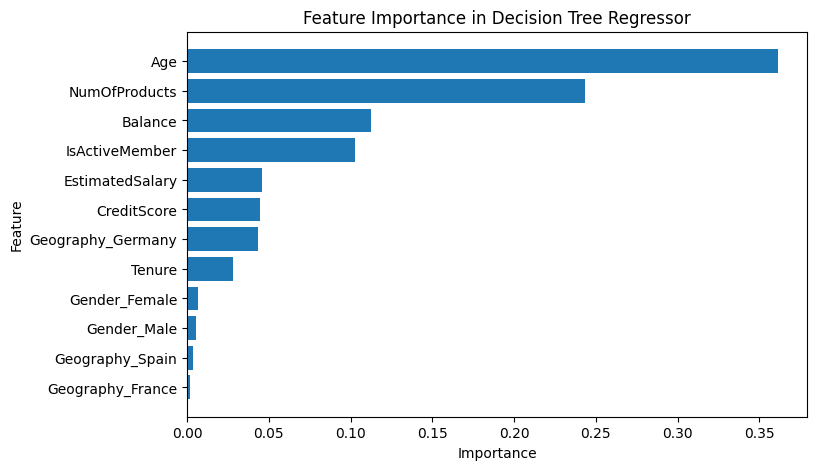

In [39]:
# Visualize feature importance as a horizontal bar chart
sorted_importance = feature_importance.sort_values(by='importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(sorted_importance['feature'], sorted_importance['importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance in Decision Tree Regressor')
plt.show()

> Age, NumOfProducts and Balance come out as the most important features, which is consistent with what was observed during EDA and in the logistic regression. IsActiveMember also remains a notable contributor.

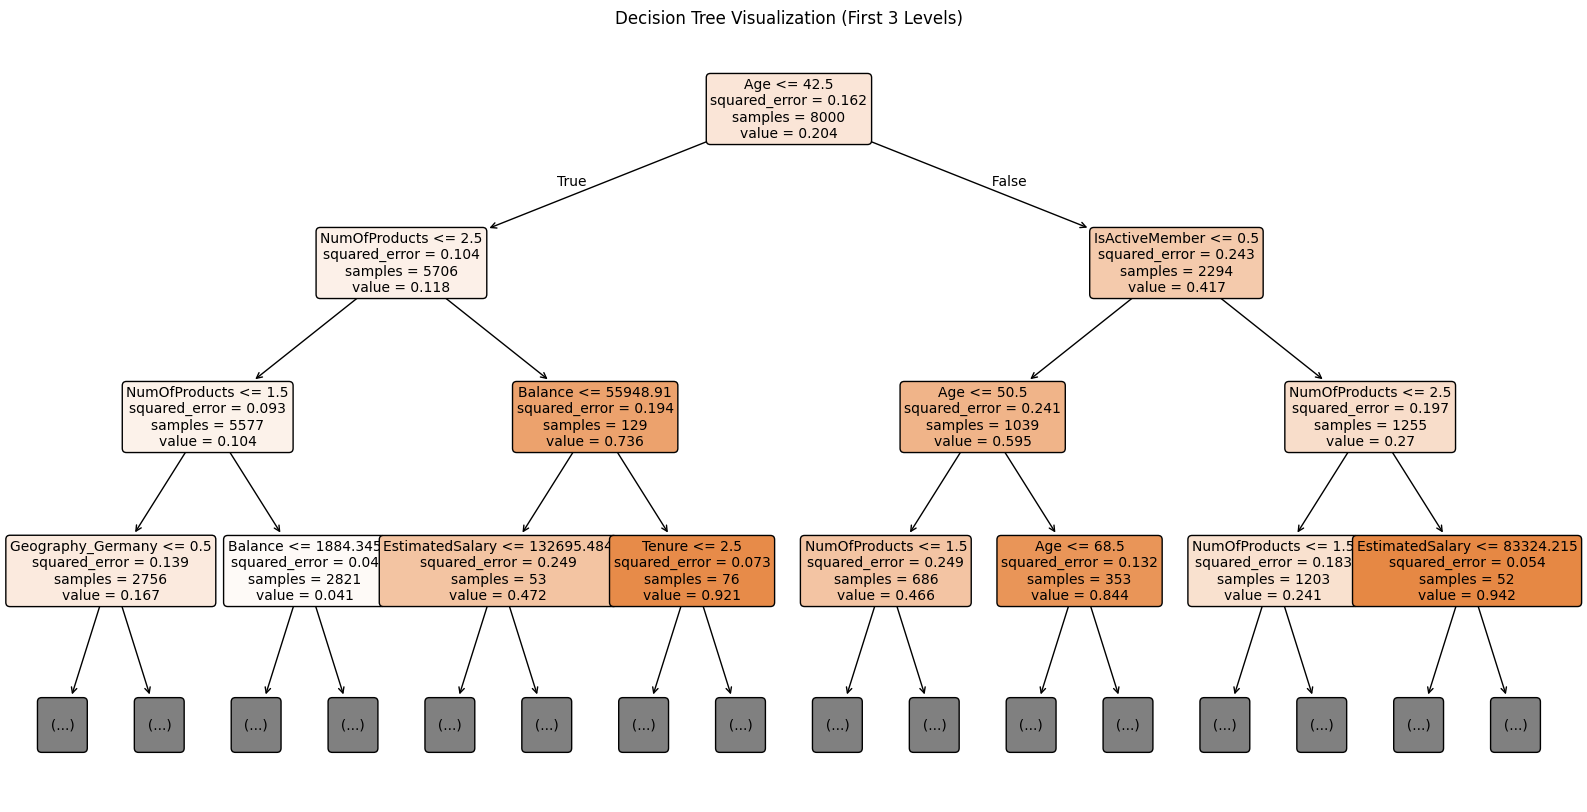

In [40]:
# Visualize the first 3 levels of the Decision Tree for readability
plt.figure(figsize=(20, 10))
features = x.columns
tree.plot_tree(df_regressor,
               feature_names=features,
               max_depth=3,
               filled=True,
               rounded=True,
               fontsize=10)
plt.title('Decision Tree Visualization (First 3 Levels)')
plt.show()

> Visualizing the top 3 levels of the tree shows the most critical decision splits. The root node reveals which feature the model considers most informative for separating churners from non-churners at the very first split.

In [41]:
# Convert continuous predictions to binary class labels.
# A threshold of 0.4 is used instead of the default 0.5 to improve
# sensitivity toward the minority class (churners).
y_pred_train_class = (y_pred_train > 0.4).astype(int)
y_pred_test_class = (y_pred_test > 0.4).astype(int)

> Since the regressor outputs probabilities, a threshold is needed to convert them into binary predictions. Lowering the threshold from 0.5 to 0.4 makes the model more aggressive in flagging potential churners, which helps address the class imbalance without needing extra libraries.

In [42]:
# Evaluate Decision Tree performance on both sets after threshold conversion
train_accuracy = accuracy_score(y_train, y_pred_train_class)
test_accuracy = accuracy_score(y_test, y_pred_test_class)

print("Decision Tree Training Accuracy:", train_accuracy)
print("Decision Tree Testing Accuracy:", test_accuracy)

Decision Tree Training Accuracy: 0.87925
Decision Tree Testing Accuracy: 0.8295


In [43]:
# Confusion matrix to evaluate classification performance on the test set
cm_tree = confusion_matrix(y_test, y_pred_test_class)
print("Confusion Matrix:")
print(cm_tree)

Confusion Matrix:
[[1440  153]
 [ 188  219]]


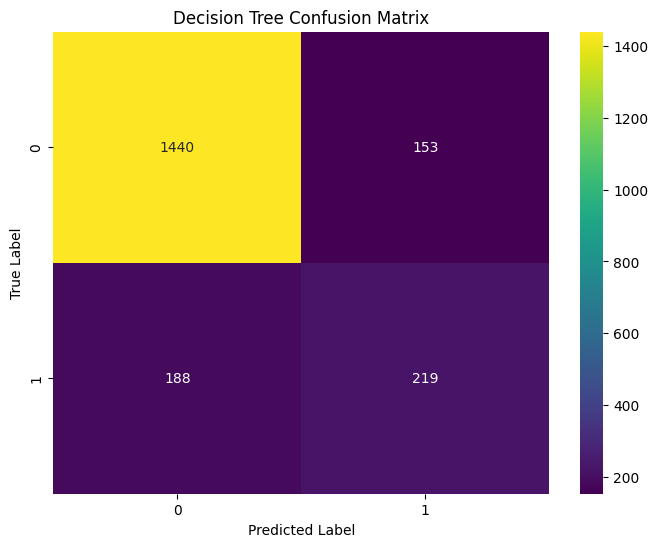

In [44]:
# Visualize the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='viridis')
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

> The Decision Tree hits a training accuracy of 87.93% and test accuracy of 82.95%, which is a decent result with no major overfitting. The confusion matrix tells the more interesting story though. With the threshold lowered to 0.4, the model caught 219 churners compared to just 77 from the original logistic regression, and false negatives dropped to 188. There is still room to improve, but this is a clear step in the right direction heading into the Random Forest.

### RANDOM FOREST REGRESSOR

In [45]:
# Train a Random Forest Regressor using 100 decision trees.
# The same constraints from the Decision Tree are applied to each tree.
# n_jobs=-1 uses all available CPU cores to speed up training.
rf_regressor = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
rf_regressor.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [46]:
# Generate averaged probability predictions from all 100 trees
y_pred_train_rf = rf_regressor.predict(x_train)
y_pred_test_rf = rf_regressor.predict(x_test)

print("Random Forest Predictions (Training Set - first 10):")
print(y_pred_train_rf[:10])
print("\nRandom Forest Predictions (Test Set - first 10):")
print(y_pred_test_rf[:10])

Random Forest Predictions (Training Set - first 10):
[0.95319726 0.33321363 0.16969392 0.00970652 0.24130009 0.02262516
 0.37452713 0.05394879 0.09375087 0.09850711]

Random Forest Predictions (Test Set - first 10):
[0.00812969 0.04079632 0.01252313 0.02852934 0.09553995 0.27541332
 0.02827324 0.0586081  0.59103771 0.10376693]


> The Random Forest averages the predictions across all 100 trees, producing smoother and more stable probability estimates compared to a single Decision Tree.

In [47]:
# Extract feature importance averaged across all 100 trees
rf_feature_importance = pd.DataFrame({
    'feature': x.columns,
    'importance': rf_regressor.feature_importances_
}).sort_values('importance', ascending=False)

display(rf_feature_importance)

,feature,importance
1,Age,0.337126
4,NumOfProducts,0.218276
3,Balance,0.123276
5,IsActiveMember,0.104592
6,EstimatedSalary,0.061473
0,CreditScore,0.060463
10,Geography_Germany,0.043106
2,Tenure,0.028553
7,Gender_Female,0.007417
8,Gender_Male,0.007095


> Averaging importance scores across 100 trees makes this ranking more robust than a single tree. The most influential features remain consistent with earlier models, lending confidence to those findings.

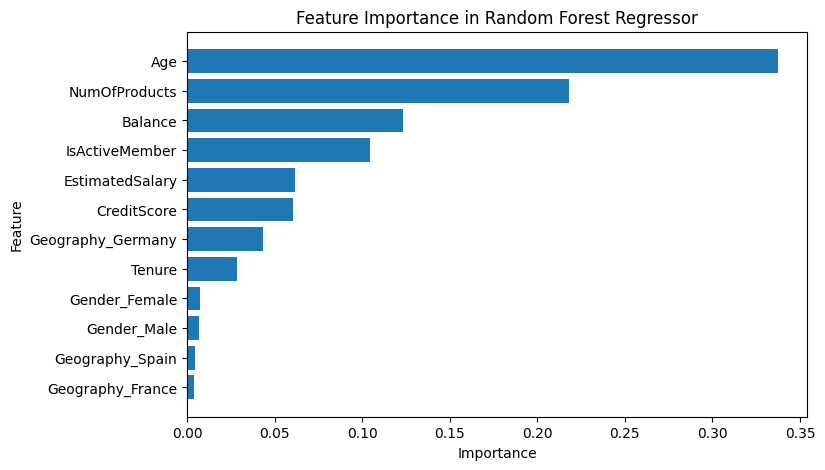

In [48]:
# Visualize Random Forest feature importance
sorted_importance_rf = rf_feature_importance.sort_values(by='importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(sorted_importance_rf['feature'], sorted_importance_rf['importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance in Random Forest Regressor')
plt.show()

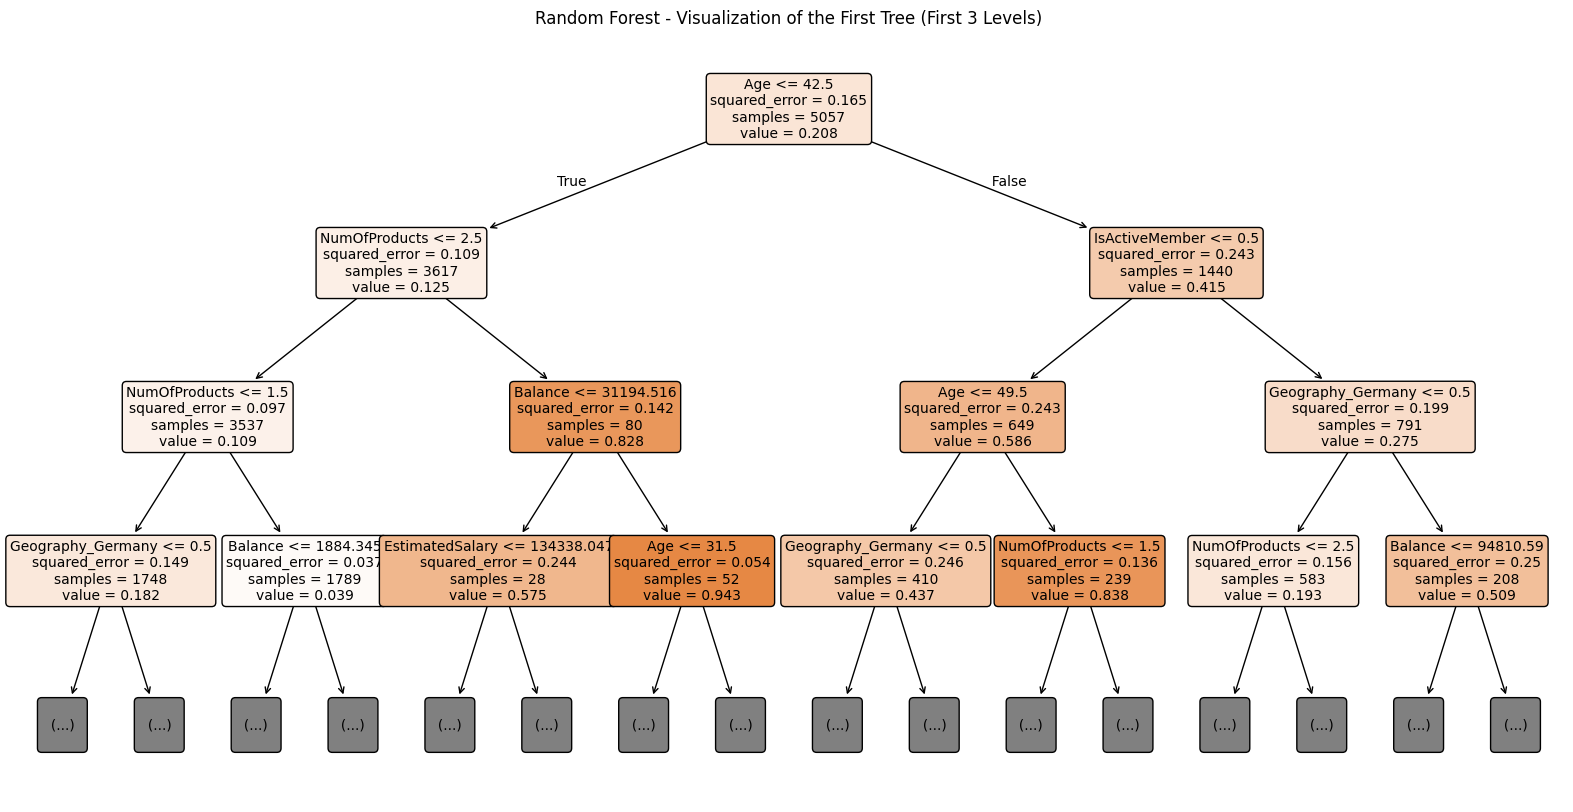

In [49]:
# Visualize the first tree in the Random Forest (first 3 levels only)
plt.figure(figsize=(20, 10))
features = x.columns
tree.plot_tree(rf_regressor.estimators_[0],
               feature_names=features,
               max_depth=3,
               filled=True,
               rounded=True,
               fontsize=10)
plt.title('Random Forest - Visualization of the First Tree (First 3 Levels)')
plt.show()

> Since the Random Forest is made up of 100 trees, only the first tree is visualized here for reference. It gives a rough idea of the structure each individual tree follows, though the full model's strength comes from combining all of them together.

In [50]:
# Convert averaged probabilities to binary class labels using a 0.4 threshold
y_pred_train_rf_class = (y_pred_train_rf > 0.3).astype(int)
y_pred_test_rf_class = (y_pred_test_rf > 0.3).astype(int)

In [51]:
# Evaluate Random Forest performance on both sets
rf_train_accuracy = accuracy_score(y_train, y_pred_train_rf_class)
rf_test_accuracy = accuracy_score(y_test, y_pred_test_rf_class)

print("Random Forest Training Accuracy:", rf_train_accuracy)
print("Random Forest Testing Accuracy:", rf_test_accuracy)

Random Forest Training Accuracy: 0.8815
Random Forest Testing Accuracy: 0.843


In [52]:
# Confusion matrix for the Random Forest on the test set
cm_rf = confusion_matrix(y_test, y_pred_test_rf_class)
print("Random Forest Confusion Matrix:")
print(cm_rf)

Random Forest Confusion Matrix:
[[1411  182]
 [ 132  275]]


> The Random Forest uses a threshold of 0.3 rather than 0.4 because while 0.4 gives a higher overall accuracy, 0.3 catches 275 churners compared to 225, with only 132 missed. In a churn prediction task, catching more at-risk customers matters more than raw accuracy, making 0.3 the better practical choice. This also makes the Random Forest the strongest performing model in the project overall.

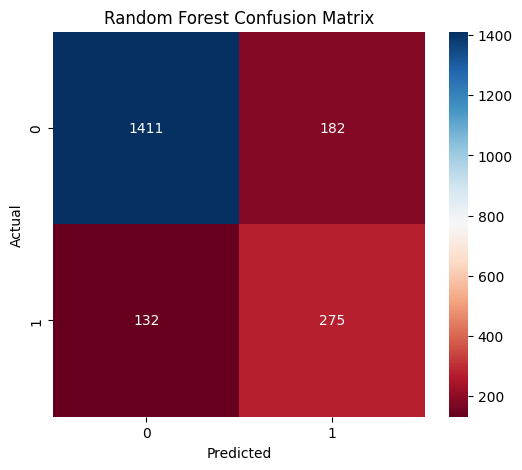

In [53]:
# Visualize the Random Forest confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='RdBu')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## CONCLUSION

This project set out to predict customer churn using three machine learning models: Logistic Regression, Decision Tree Regressor, and Random Forest Regressor. Each model brought something different to the table, and looking at them together tells a clearer story than any one model alone.

The Logistic Regression with class balancing achieved a test accuracy of 71.45% but was the best at catching churners, identifying 287 out of 407. The class_weight='balanced' parameter was key here since without it the model would simply predict the majority class most of the time and miss nearly all churners.

The Decision Tree improved overall accuracy to 82.95% and with a threshold of 0.4 correctly identified 219 churners. It captured nonlinear patterns that logistic regression could not, and the tree visualization makes the decision logic easy to follow.

The Random Forest was the strongest performer overall. By aggregating 100 decision trees and using a threshold of 0.3, it caught 275 churners with only 132 missed, achieving a test accuracy of 84.30%. The lower threshold was a deliberate choice, prioritizing churn detection over raw accuracy since missing an at-risk customer is far more costly than a false alarm in a real banking context.

Across all three models, Age, NumOfProducts, Balance, and IsActiveMember consistently emerged as the most important predictors of churn. These findings align with the patterns observed during EDA, which gives confidence that the models are picking up on real signals rather than noise.

Overall, this project demonstrates that machine learning can meaningfully support customer retention efforts. With the right model and the right evaluation focus, banks can identify at-risk customers early and act before they leave.